# Un catalizador que convierte basura en combustible — y aguanta 850 horas

**50 catalizadores compiten por la misma reacción. Solo uno llega al 99% de conversión y encima no se cansa.**

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Industrial-scale nanocrystalline Ni–Mo–MgO catalysts for hybrid reforming of waste to fuels* · Science (2026)

**DOI:** [10.1126/science.adp5208](https://doi.org/10.1126/science.adp5208)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-25-nimocat-reformado-residuos/notebook.ipynb)

**Video:** *en producción*

## De qué va esto

La idea suena a alquimia, pero es química de reactor: agarras metano (o los gases sucios que salen de quemar basura), le metes CO₂ y lo pasas caliente por un metal. Sale **gas de síntesis** (H₂ + CO), la materia prima con la que se fabrican combustibles líquidos y plásticos. Doble premio: te comes CO₂ *y* conviertes residuos en algo vendible.

El problema de siempre es el catalizador. Se llena de hollín (coque), se apaga y hay que cambiarlo. La carrera de los últimos años ha sido encontrar uno que aguante. Este equipo dice tener el que gana — y publica una tabla con 50 rivales para que lo compares. Abramos esa tabla.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CATALIZADOR_ESTRELLA = 'NiMoCat'
UMBRAL_ALTO_CH4      = 99      # % conversión que define "élite"
COLOR_DATOS       = '#2563EB'  # azul  — estables
COLOR_ALERTA      = '#DC2626'  # rojo  — NiMoCat / referencia
COLOR_SECUNDARIO  = '#059669'  # verde — CO2
COLOR_REFERENCIA  = '#D97706'  # ámbar — umbrales
COLOR_CONTEXTO    = '#BBBBBB'  # gris  — se desactiva
FUENTE = 'Fuente: Science (2026), DOI 10.1126/science.adp5208 | Datos: Tablas S1/S2/S4 (Supplementary)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 3 datasets (Supplementary del paper)
cat     = pd.read_csv('datos/catalizadores_drm.csv')   # 50 catalizadores comparados
pellets = pd.read_csv('datos/conversion_pellets.csv')  # polvo vs pellets industriales
tof     = pd.read_csv('datos/tof_temperatura.csv')      # actividad por temperatura

nimo = cat[cat['catalizador'] == CATALIZADOR_ESTRELLA]
campo = cat[cat['catalizador'] != CATALIZADOR_ESTRELLA]

print(f'Catalizadores en la comparación: {len(cat)}')
print(f'{CATALIZADOR_ESTRELLA}: {int(nimo["conversion_ch4_pct"].iloc[0])}% CH4, '
      f'{int(nimo["conversion_co2_pct"].iloc[0])}% CO2, '
      f'{int(nimo["tiempo_estabilidad_h"].iloc[0])} h en operación')
print(f'Resto del campo (n={len(campo)}): '
      f'CH4 mediana {campo["conversion_ch4_pct"].median():.0f}% '
      f'(rango {campo["conversion_ch4_pct"].min():.0f}-{campo["conversion_ch4_pct"].max():.0f}%)')
print(f'Con >= {UMBRAL_ALTO_CH4}% CH4: '
      f'{(cat["conversion_ch4_pct"] >= UMBRAL_ALTO_CH4).sum()} de {len(cat)}')

Catalizadores en la comparación: 50
NiMoCat: 99% CH4, 100% CO2, 850 h en operación
Resto del campo (n=49): CH4 mediana 79% (rango 5-97%)
Con >= 99% CH4: 1 de 50


Aquí están los 50. Cada punto es un catalizador publicado.

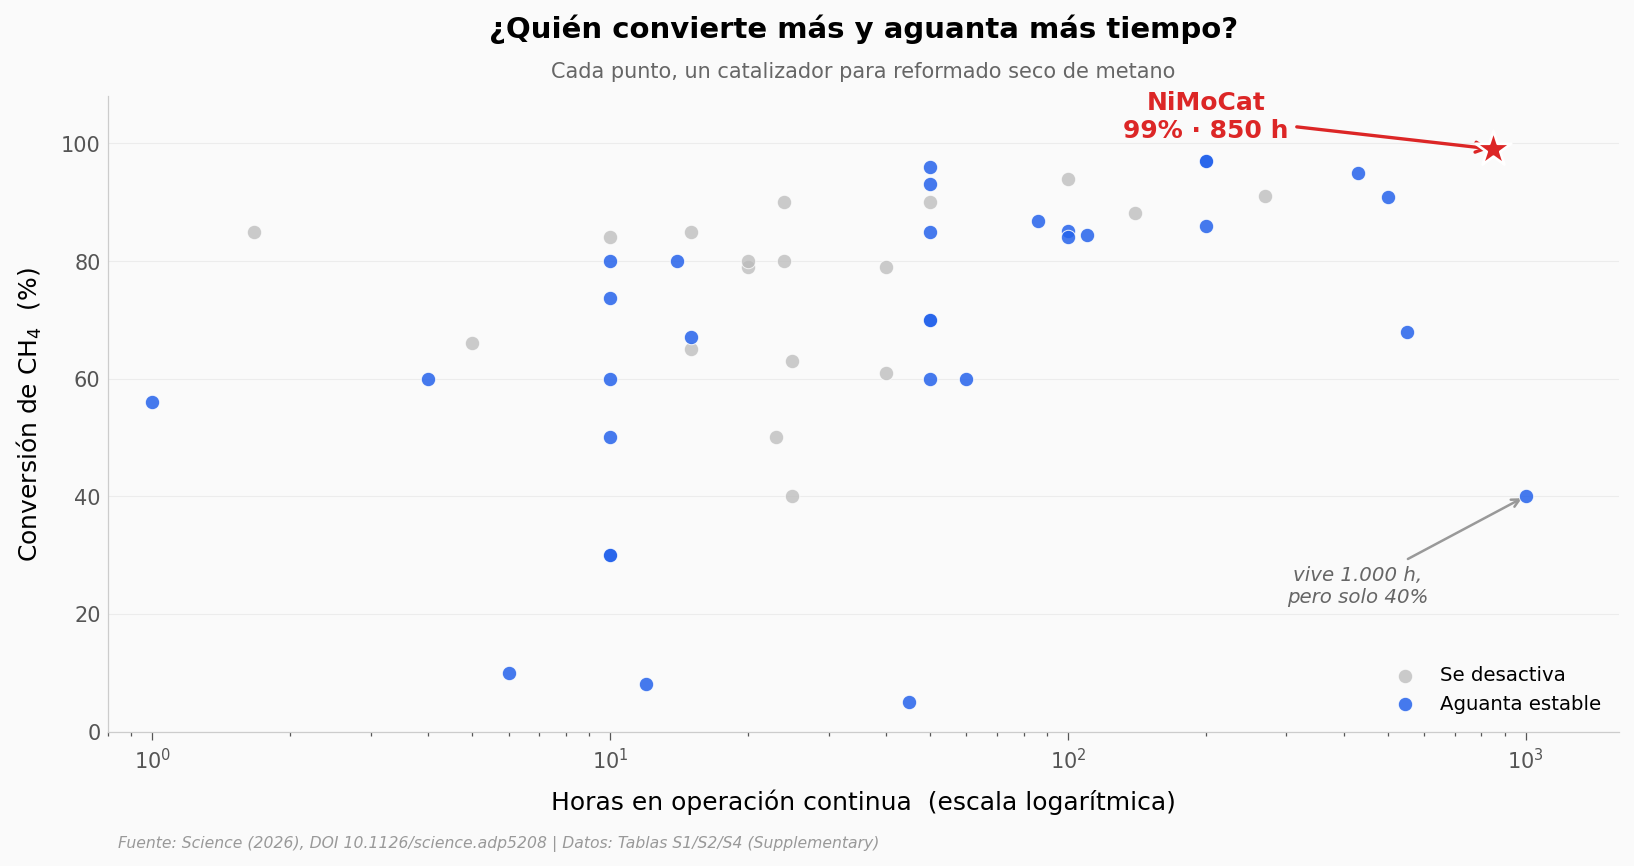

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

estables   = campo[campo['se_desactiva'] == 0]
inestables = campo[campo['se_desactiva'] == 1]

ax.scatter(inestables['tiempo_estabilidad_h'], inestables['conversion_ch4_pct'],
           color=COLOR_CONTEXTO, s=48, alpha=0.75, edgecolors='white',
           linewidths=0.5, zorder=3, label='Se desactiva')
ax.scatter(estables['tiempo_estabilidad_h'], estables['conversion_ch4_pct'],
           color=COLOR_DATOS, s=48, alpha=0.85, edgecolors='white',
           linewidths=0.5, zorder=4, label='Aguanta estable')
ax.scatter(nimo['tiempo_estabilidad_h'], nimo['conversion_ch4_pct'],
           color=COLOR_ALERTA, s=320, marker='*', edgecolors='white',
           linewidths=1.3, zorder=6)

ax.set_xscale('log')
ax.set_xlim(0.8, 1600)
ax.set_ylim(0, 108)

# NiMoCat: la estrella, arriba a la derecha
ax.annotate('NiMoCat\n99% · 850 h', xy=(850, 99), xytext=(200, 101),
            fontsize=12, fontweight='bold', color=COLOR_ALERTA, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.6))
# El que más dura pero no convierte: vive mucho, rinde poco
ax.annotate('vive 1.000 h,\npero solo 40%', xy=(1000, 40), xytext=(430, 22),
            fontsize=9.5, color='#666666', ha='center', style='italic',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.2))

ax.set_title('¿Quién convierte más y aguanta más tiempo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto, un catalizador para reformado seco de metano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Horas en operación continua  (escala logarítmica)')
ax.set_ylabel('Conversión de CH$_4$  (%)')
ax.legend(loc='lower right', fontsize=9.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/campo_pareto.png', dpi=200, bbox_inches='tight')
plt.show()

La multitud se apiña abajo a la izquierda: poca vida, conversión mediana (79% en el campo). Subir el rendimiento **o** durar mucho ya cuesta; hacer las dos cosas a la vez es la esquina vacía de arriba a la derecha.

Ahí, solo, está NiMoCat. Es el único de los 50 que cruza el 99% de conversión, y encima lleva 850 horas sin apagarse. El punto gris que vive 1.000 horas engaña: aguanta, sí, pero se queda en 40% — durar no sirve de nada si conviertes poco.

Un matiz honesto: esta tabla junta resultados medidos en condiciones distintas (temperatura, flujo, tipo de alimentación). El propio pie de la tabla del paper lo dice — es un mapa **indicativo** del terreno, no un pique controlado uno contra uno.

Pero hay una trampa al salir del laboratorio. Ese 99% se midió con el catalizador en **polvo**. Ninguna fábrica hace pasar gas a presión por un polvo fino — se necesita prensarlo en **pellets**. ¿Cuánto se paga por ese cambio de forma?

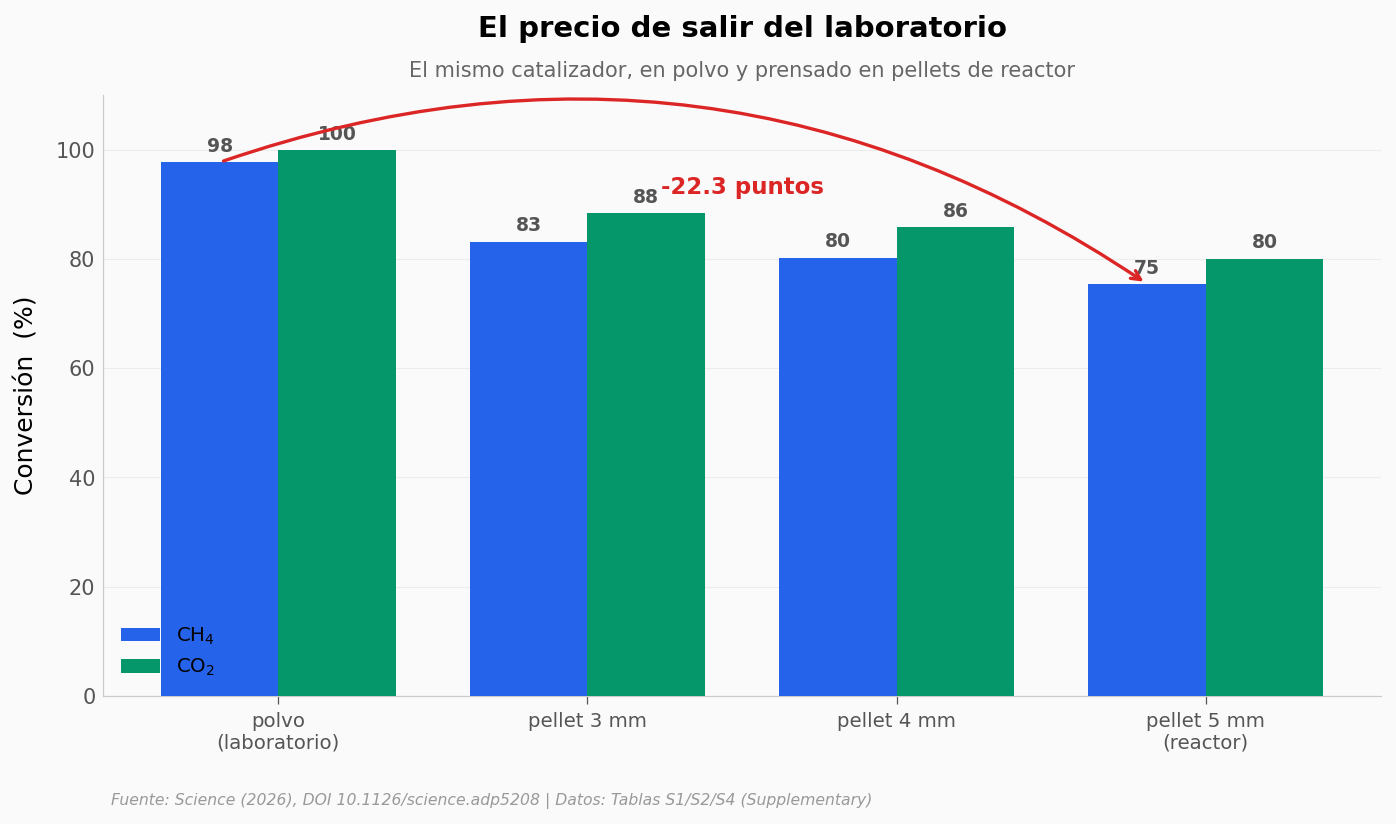

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.2))

orden = ['polvo', 'pellet 3 mm', 'pellet 4 mm', 'pellet 5 mm']
p = pellets.set_index('forma').loc[orden].reset_index()
x = np.arange(len(orden))
w = 0.38

b1 = ax.bar(x - w/2, p['conversion_ch4_pct'], w, color=COLOR_DATOS,
            label='CH$_4$', zorder=3)
b2 = ax.bar(x + w/2, p['conversion_co2_pct'], w, color=COLOR_SECUNDARIO,
            label='CO$_2$', zorder=3)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.2, f'{h:.0f}',
                ha='center', va='bottom', fontsize=9, color='#555555',
                fontweight='bold')

# Flecha de la caída polvo -> pellet 5 mm (CH4)
caida = p['conversion_ch4_pct'].iloc[0] - p['conversion_ch4_pct'].iloc[3]
ax.annotate('', xy=(3 - w/2, p['conversion_ch4_pct'].iloc[3]),
            xytext=(0 - w/2, p['conversion_ch4_pct'].iloc[0]),
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.6,
                            connectionstyle='arc3,rad=-0.25'))
ax.text(1.5, 92, f'-{caida:.1f} puntos', color=COLOR_ALERTA,
        fontsize=11, fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(['polvo\n(laboratorio)', 'pellet 3 mm', 'pellet 4 mm',
                    'pellet 5 mm\n(reactor)'], fontsize=9.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Conversión  (%)')
ax.set_title('El precio de salir del laboratorio',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El mismo catalizador, en polvo y prensado en pellets de reactor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='lower left', fontsize=9.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escalado_pellet.png', dpi=200, bbox_inches='tight')
plt.show()

Queda una perilla más: la **temperatura**. Cada sitio activo del catalizador trabaja más rápido cuanto más caliente esté. Esa velocidad por sitio se mide con el TOF (*turnover frequency*: cuántas moléculas transforma cada sitio por segundo).

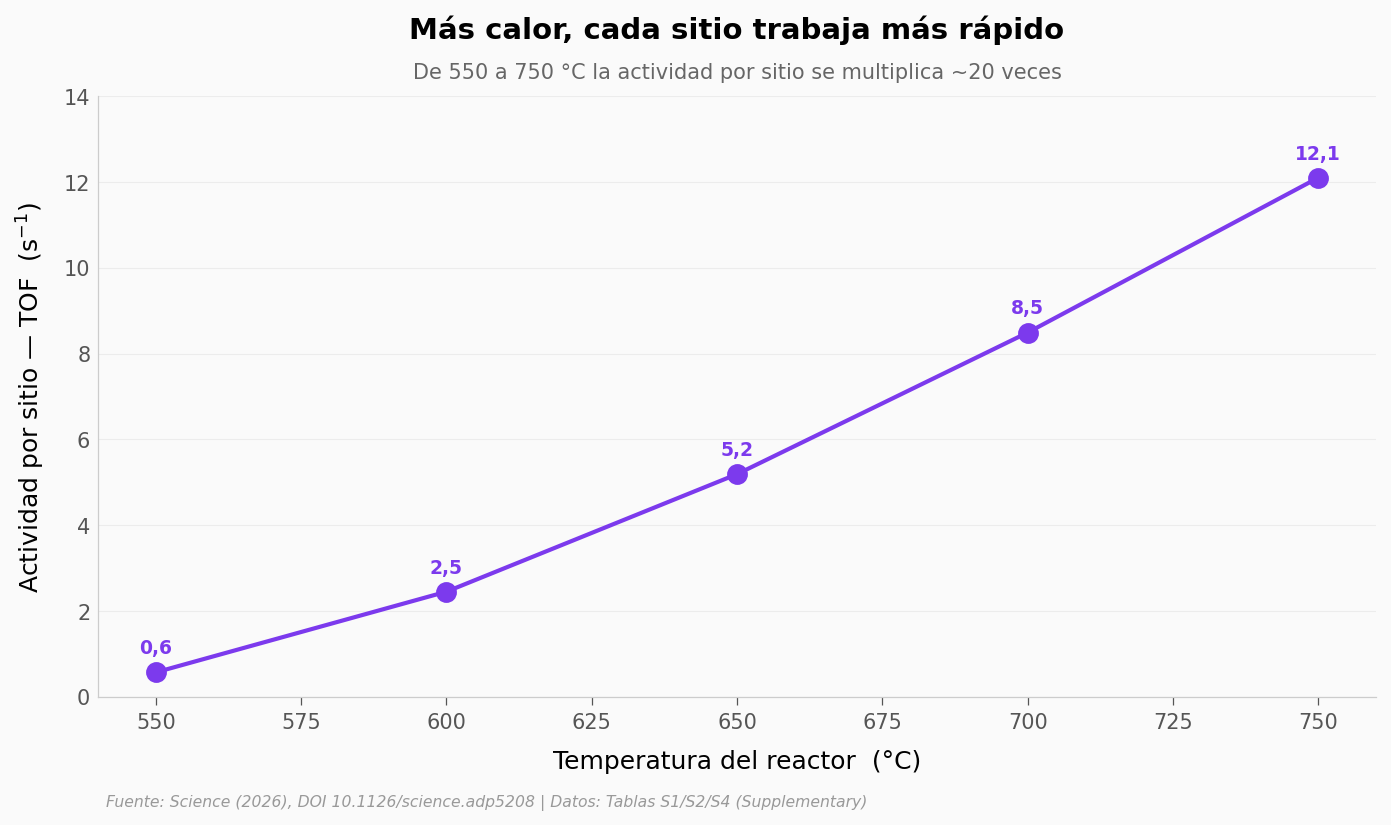

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.2))

t = tof.sort_values('temperatura_c')
ax.plot(t['temperatura_c'], t['tof_s1'], marker='o', markersize=9,
        color='#7C3AED', linewidth=2, zorder=4)
for _, r in t.iterrows():
    ax.annotate(f"{r['tof_s1']:.1f}".replace('.', ','), xy=(r['temperatura_c'], r['tof_s1']),
                xytext=(0, 9), textcoords='offset points', ha='center',
                fontsize=9, color='#7C3AED', fontweight='bold')

ax.set_xlabel('Temperatura del reactor  (°C)')
ax.set_ylabel('Actividad por sitio — TOF  (s$^{-1}$)')
ax.set_ylim(0, 14)
ax.set_title('Más calor, cada sitio trabaja más rápido',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'De 550 a 750 °C la actividad por sitio se multiplica ~20 veces',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tof_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

Ese salto de actividad con la temperatura tiene un costo energético que el equipo midió: la energía de activación del consumo de CH₄ es de ~79 kJ/mol (un dato que ellos calculan en régimen diferencial, no algo que reproduzcamos aquí con estos cinco puntos).

Volvamos al premio gordo. Con todo el campo enfrente: **¿qué tan raro es de verdad llegar al 99%?**

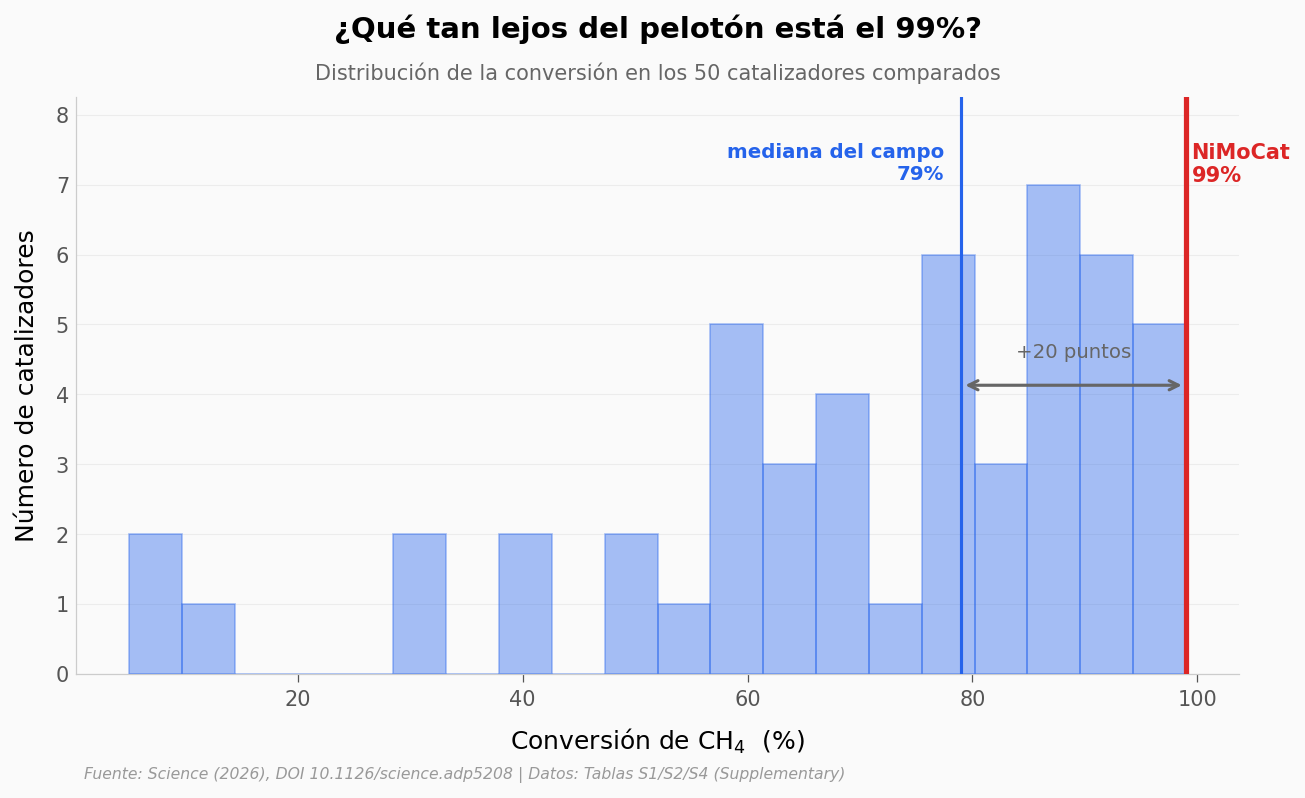

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ch4 = cat['conversion_ch4_pct'].dropna()
mediana = campo['conversion_ch4_pct'].median()
valor_nimo = float(nimo['conversion_ch4_pct'].iloc[0])

n, bins, patches = ax.hist(ch4, bins=20, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8, zorder=3)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5, zorder=4)
ax.text(mediana - 1.5, y_max * 0.92, f'mediana del campo\n{mediana:.0f}%',
        ha='right', va='top', fontsize=9.5, color=COLOR_DATOS, fontweight='bold')

ax.axvline(x=valor_nimo, color=COLOR_ALERTA, linewidth=2.5, zorder=5)
ax.text(valor_nimo + 0.5, y_max * 0.92, f'NiMoCat\n{valor_nimo:.0f}%',
        ha='left', va='top', fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.annotate('', xy=(valor_nimo, y_max * 0.5), xytext=(mediana, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + valor_nimo) / 2, y_max * 0.54, f'+{valor_nimo - mediana:.0f} puntos',
        ha='center', va='bottom', fontsize=9.5, color='#666666')

ax.set_xlabel('Conversión de CH$_4$  (%)')
ax.set_ylabel('Número de catalizadores')
ax.set_title('¿Qué tan lejos del pelotón está el 99%?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Distribución de la conversión en los {len(cat)} catalizadores comparados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_conversion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| NiMoCat es el único de los 50 con ≥99% de CH₄ | ✅ | 1 de 50 en la Tabla S1; el máximo del resto del campo es 97% |
| Aguanta 850 h de operación | ✅ | Tiempo en operación de 850 h reportado en Tabla S1. De los cuatro catalizadores que llegan o pasan las 500 h, es el único que además mantiene conversión alta (99%); los otros tres se quedan entre 40% y 91% |
| Al pasar de polvo a pellet la conversión cae ~22 puntos | ✅ | Tabla S4: polvo 97,7% → pellet 5 mm 75,4% CH₄. La caída se atenúa con pellets más pequeños (3 mm: 83,2%) |
| La actividad por sitio sube ~20× de 550 a 750 °C | ✅ | Tabla S2: TOF 0,57 → 12,1 s⁻¹ |
| Energía de activación del CH₄ ≈ 79 kJ/mol | ⚠️ | Valor **reportado por el paper** (régimen diferencial). Un ajuste ingenuo sobre los 5 puntos de TOF **no** lo reproduce — no lo recalculamos aquí |
| Produce gas de síntesis "cuantitativo" | ✅ | El paper reporta selectividad cercana al 100%; no equivale a "sin ninguna pérdida" |

> **Limitaciones:**
> - La comparación de la Tabla S1 junta estudios medidos en condiciones distintas (temperatura, flujo, alimentación). Es un mapa indicativo, no un ensayo cabeza a cabeza controlado — lo dice el propio pie de tabla del paper.
> - "Escala industrial" aquí significa síntesis a escala de kilogramos y prueba en reactor de alta presión; **no** que ya esté desplegado en plantas comerciales.
> - El análisis de ciclo de vida (biogás → dimetil éter) es una demostración de caso que hacen los autores, no una prueba universal de sostenibilidad.

### Ahora tú

1. **¿Y si la métrica no fuera la conversión, sino el rendimiento por gramo de catalizador?** La columna `sty_ch4` (gramos de CH₄ por gramo de catalizador por hora) cuenta otra historia. Ordena el campo por `sty_ch4` — ¿sigue ganando NiMoCat, o aparecen otros nombres? *Pista: `cat.sort_values('sty_ch4', ascending=False).head(10)`*

2. **¿La calidad del gas de síntesis importa?** La relación H₂/CO (`ratio_h2_co`) decide para qué sirve el gas: cerca de 1 es ideal para hacer combustibles líquidos. ¿Cuántos catalizadores rondan ese 1,0? *Pista: filtra `cat[(cat.ratio_h2_co > 0.9) & (cat.ratio_h2_co < 1.1)]`*

3. **¿A qué temperatura trabaja cada uno?** Grafica `temperatura_c` contra `conversion_ch4_pct`. ¿Los que más convierten necesitan más calor? *Pista: `ax.scatter(cat.temperatura_c, cat.conversion_ch4_pct)`*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cambia el ranking si miramos rendimiento por gramo (STY) en vez de % conversión?

top_sty = cat.sort_values('sty_ch4', ascending=False)[
    ['catalizador', 'sty_ch4', 'conversion_ch4_pct', 'tiempo_estabilidad_h']
].head(10)

print('Top 10 por rendimiento (gCH4 / gcat / h):')
print(top_sty.to_string(index=False))

pos_nimo = cat.sort_values('sty_ch4', ascending=False).reset_index(drop=True)
pos = pos_nimo.index[pos_nimo['catalizador'] == CATALIZADOR_ESTRELLA][0] + 1
print(f'\nNiMoCat queda en el puesto {pos} de {len(cat)} por STY '
      f'(STY = {nimo["sty_ch4"].iloc[0]}).')
print('Gana en durabilidad y conversión, no en rendimiento bruto por gramo.')

Top 10 por rendimiento (gCH4 / gcat / h):
      catalizador  sty_ch4  conversion_ch4_pct  tiempo_estabilidad_h
     Ni5-600-1000   153.98                50.0                  10.0
     Ni/SBA-15-DP    48.12                61.0                  40.0
       Ni0.44@S-1    18.94                85.1                 100.0
   Ni-3La2O3/SiO2    18.05                79.0                  40.0
Ni3Fe1/CeO2-Al2O3    14.78                73.7                  10.0
       Ni-In/SiO2    12.91                80.0                  24.0
      7Ni3Co/SiO2    11.22                84.0                 100.0
      Ni-Co/La2O3    10.74                30.0                  10.0
         Ni@Al2O3    10.35                90.0                  50.0
    0.5Cu-Ni@SiO2    10.23                85.0                  50.0

NiMoCat queda en el puesto 28 de 50 por STY (STY = 3.97).
Gana en durabilidad y conversión, no en rendimiento bruto por gramo.


---

### Sobre este notebook

Reproducible de punta a punta: los datos vienen de las tablas suplementarias del paper (transcritas a CSV), y cada gráfica se genera con el código de arriba.

## Fuentes

**Paper**: [Industrial-scale nanocrystalline Ni–Mo–MgO catalysts for hybrid reforming of waste to fuels](https://doi.org/10.1126/science.adp5208) · paywall  
*Science, 2026-06-25*

**Supplementary Material**: [Tablas S1 (50 catalizadores), S2 (TOF), S4 (pellets)](https://www.science.org/doi/suppl/10.1126/science.adp5208/suppl_file/science.adp5208_sm.pdf)  
*mismo DOI, peer-reviewed*

*16 afirmaciones del notebook verificadas contra estas fuentes*